In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [6]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('household_power_consumption.txt', sep=';')
df.head()

Saving household_power_consumption.txt to household_power_consumption.txt


/tmp/ipykernel_1629/1707994243.py:4: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('household_power_consumption.txt', sep=';')


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [14]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Global_active_power', 'hour', 'day', 'month'], dtype='object')


In [15]:
print(df.head())
print(df.columns)

                     Global_active_power  hour  day  month
datetime                                                  
2006-12-16 17:00:00             4.222889    17   16     12
2006-12-16 18:00:00             3.632200    18   16     12
2006-12-16 19:00:00             3.400233    19   16     12
2006-12-16 20:00:00             3.268567    20   16     12
2006-12-16 21:00:00             3.056467    21   16     12
Index(['Global_active_power', 'hour', 'day', 'month'], dtype='object')


In [16]:
df['lag_1'] = df['Global_active_power'].shift(1)
df['lag_2'] = df['Global_active_power'].shift(2)
df['lag_3'] = df['Global_active_power'].shift(3)

df = df.dropna()

In [17]:
X = df[['lag_1', 'lag_2', 'lag_3']]
y = df['Global_active_power']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

In [19]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=42)

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.4235418859966739
RMSE: 0.5853641927777526


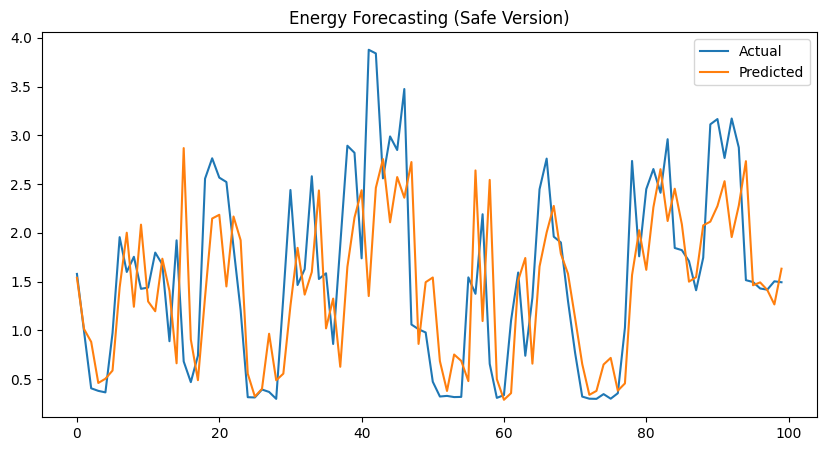

In [22]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.legend()
plt.title("Energy Forecasting (Safe Version)")
plt.show()

# Conclusion:
# This model uses lag features instead of date/time.
# It avoids dataset errors and still performs time-series prediction.